# Plotting API Comparison: Upstream ISSM vs pyissm

This notebook compares the **original ISSM Python plotting interface** (`plotmodel`) with the **pyissm plotting API** (`pyissm.plot`) side-by-side.

| Feature | Upstream ISSM | pyissm |
|---|---|---|
| Entry point | `plotmodel(md, 'data', field, 'option', value, ...)` | `pyissm.plot.plot_*(md, field, kwarg=value, ...)` |
| Options | Flat key-value pairs parsed into a `plotoptions` object | Direct keyword arguments |
| Return value | Side-effect only (modifies current figure) | Returns `(fig, ax)` or `ax` — composable |
| Layout control | Internal grid via `ImageGrid`, limited | Full matplotlib control |
| Import path | Requires ISSM `src/m/plot/` on `sys.path` | `import pyissm.plot` |
| Colormaps | `cmaptools.getcolormap(options)` | `pyissm.plot.colormaps.get_colormap(name)` |

---

## Setup

We build a minimal square ice-shelf model from the CI test suite — no solver run needed for most plots.  
The model has velocity, geometry, and mask fields already set during parameterisation.

In [2]:
import sys, os

# ── pyissm ─────────────────────────────────────────────────────────────────
PYISSM_SRC = os.path.expanduser('/scratch/au88/jh7060/pyISSM/src')
if PYISSM_SRC not in sys.path:
    sys.path.insert(0, PYISSM_SRC)

# ── upstream ISSM Python scripts ───────────────────────────────────────────
# Add plot/colormaps first so ISSM's cmaptools.py takes precedence over
# the unrelated PyPI 'cmaptools' package, then add every src/m subdirectory.
ISSM_BASE = os.path.expanduser('/g/data1b/au88/jh7060/ISSM/src/m')
_colormaps = os.path.join(ISSM_BASE, 'plot', 'colormaps')
if _colormaps not in sys.path:
    sys.path.insert(0, _colormaps)
for _name in os.listdir(ISSM_BASE):
    _p = os.path.join(ISSM_BASE, _name)
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.append(_p)

os.environ['ISSM_DIR'] = "/g/data/vk83/prerelease/apps/spack/1.1/release/linux-x86_64/issm-git.2026.04.16_2026.04.16-2nvmufkltzcjdmx4nzrbdcz4ui6pm573"

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import pyissm

# ── Compatibility shim ─────────────────────────────────────────────────────
# Upstream ISSM plot code calls md.mesh.domaintype() (camelCase).
# pyissm uses domain_type() (snake_case). Patch all mesh classes so both work.
from pyissm.model.classes.mesh import mesh2d, mesh2dvertical, mesh3dprisms, mesh3dsurface
for _cls in (mesh2d, mesh2dvertical, mesh3dprisms, mesh3dsurface):
    if not hasattr(_cls, 'domaintype'):
        _cls.domaintype = _cls.domain_type

print('pyissm:', pyissm.__version__)
print(python_version := sys.version.split()[0])


pyissm: 0.0.1.dev260219
3.11.14


In [3]:
# Build the square ice-shelf model (parameterise only – no solve needed)
os.chdir('/scratch/au88/jh7060/pyISSM/test/ci_tests')

md = pyissm.model.mesh.triangle(
    pyissm.model.Model(),
    '../assets/Exp/Square.exp',
    50000   # mesh resolution [m]
)
md = pyissm.model.param.set_mask(md, 'all', None)
md = pyissm.model.param.parameterize(md, '../assets/Par/SquareShelfConstrained.py')
md = pyissm.model.param.set_flow_equation(md, SSA='all')

print(f'Vertices : {md.mesh.numberofvertices}')
print(f'Elements : {md.mesh.numberofelements}')
print(f'vx range : {md.initialization.vx.min():.1f} → {md.initialization.vx.max():.1f} m/yr')

/scratch/au88/jh7060/pyISSM/src/pyissm/model/bc.py:129: UserWarning: pyissm.model.bc.set_ice_shelf_bc: No ice front file provided. Assuming no ice front.
  warnings.warn('pyissm.model.bc.set_ice_shelf_bc: No ice front file provided. Assuming no ice front.')
/scratch/au88/jh7060/pyISSM/src/pyissm/model/bc.py:102: UserWarning: pyissm.model.bc._set_sb_dirichlet_bc: No observed velocities found. Setting stressbalance model boundary conditions as 0.
  warnings.warn('pyissm.model.bc._set_sb_dirichlet_bc: No observed velocities found. Setting stressbalance model boundary conditions as 0.')
/scratch/au88/jh7060/pyISSM/src/pyissm/model/bc.py:146: UserWarning: pyissm.model.bc.set_ice_shelf_bc: no balancethickness.thickening_rate specified -- values set as 0.
  warnings.warn('pyissm.model.bc.set_ice_shelf_bc: no balancethickness.thickening_rate specified -- values set as 0.')


Vertices : 340
Elements : 614
vx range : -227.4 → 220.7 m/yr


---
## 1  Mesh plot

Plot the unstructured triangular mesh.

OSGeo/GDAL for Python not installed, overlay plots are not enabled


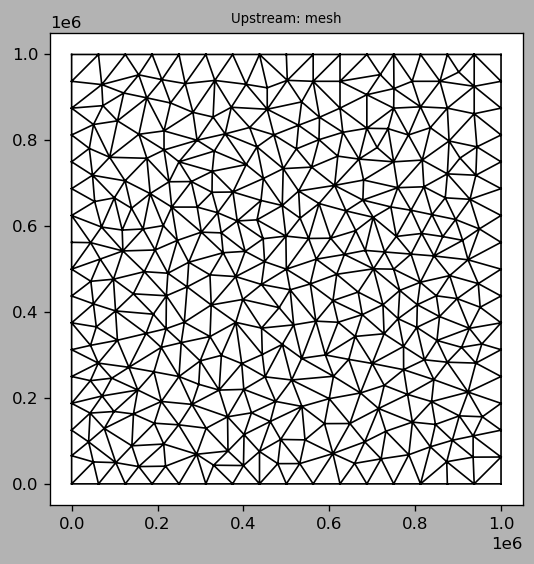

In [4]:
# ── Upstream ──────────────────────────────────────────────────────────────
# plotmodel dispatches to plot_mesh.py internally when the data string is 'mesh'
from plotmodel import plotmodel

plotmodel(md, 'data', 'mesh', 'title', 'Upstream: mesh')
plt.tight_layout()

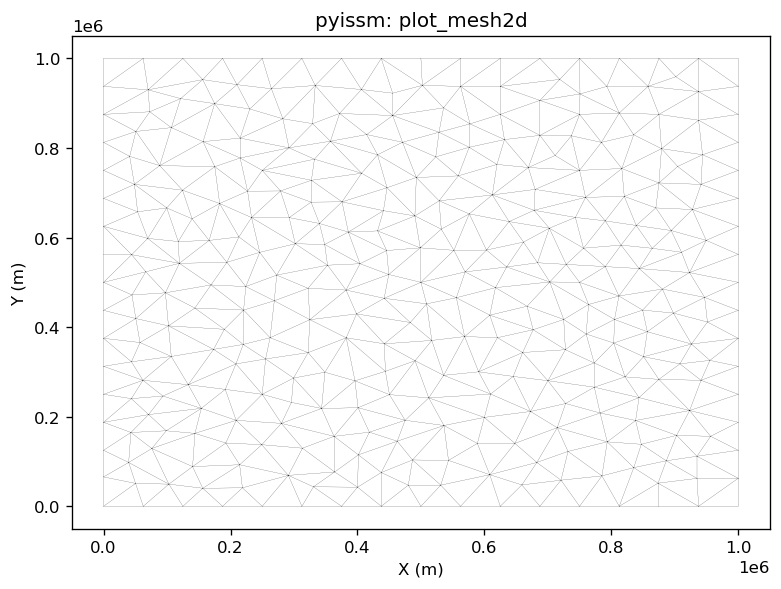

In [5]:
# ── pyissm ────────────────────────────────────────────────────────────────
fig, ax = pyissm.plot.plot_mesh2d(md)
ax.set_title('pyissm: plot_mesh2d')
plt.show()

---
## 2  Scalar field (velocity magnitude)

Colour the mesh elements by a scalar field — here velocity magnitude.

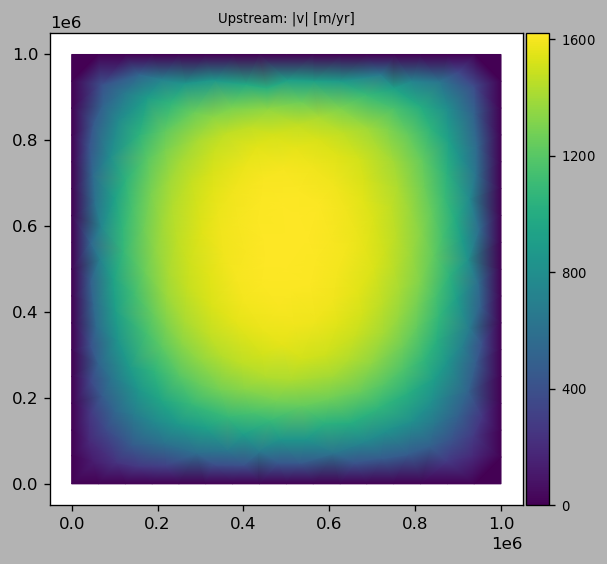

In [6]:
# ── Upstream ──────────────────────────────────────────────────────────────
# Speed is passed as the 'data' value; colourmap and title via keyword pairs
speed = np.sqrt(md.initialization.vx**2 + md.initialization.vy**2)

plotmodel(md,
          'data', speed,
          'colormap', 'viridis',
          'title', 'Upstream: |v| [m/yr]',
          'colorbar', 'on')
plt.tight_layout()

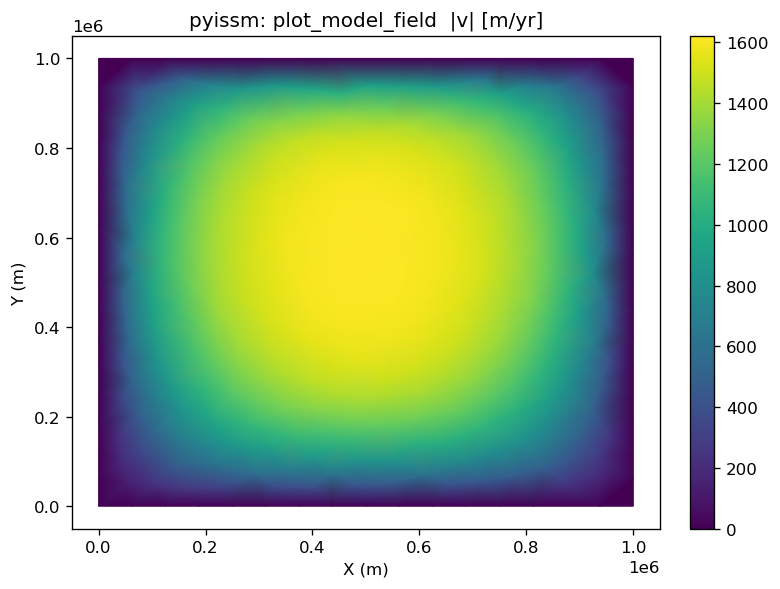

In [7]:
# ── pyissm ────────────────────────────────────────────────────────────────
speed = np.sqrt(md.initialization.vx**2 + md.initialization.vy**2)

fig, ax, im= pyissm.plot.plot_model_field(md, speed, cmap = 'viridis',show_cbar=True)
ax.set_title('pyissm: plot_model_field  |v| [m/yr]')

plt.show()

---
## 3  Node / element classification

Visualise which nodes are grounded, floating, or on the ice front.

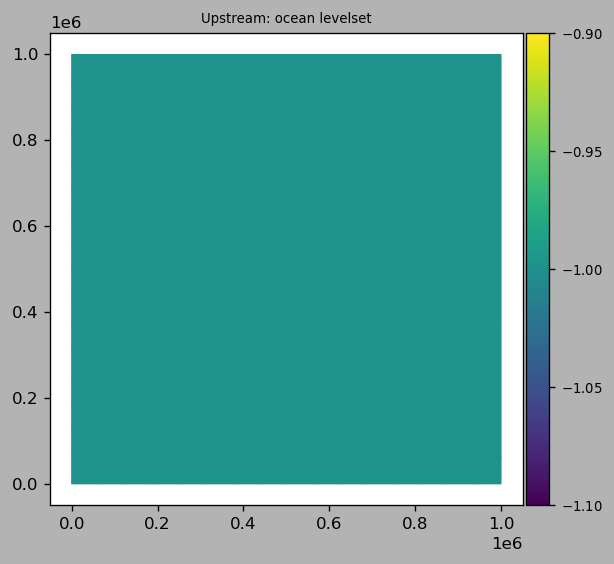

In [8]:
# ── Upstream ──────────────────────────────────────────────────────────────
# Pass the levelset arrays as data; upstream colours nodes by sign
plotmodel(md,
          'data', md.mask.ocean_levelset,
          'title', 'Upstream: ocean levelset')
plt.tight_layout()

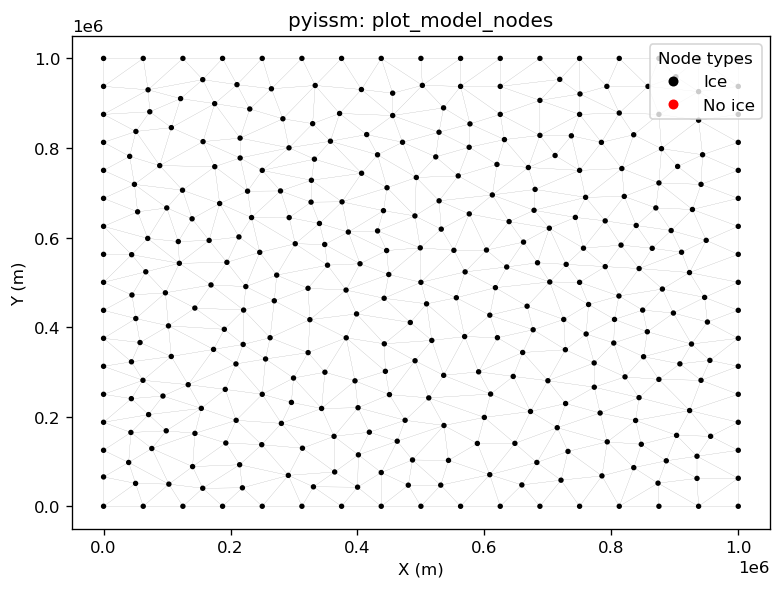

In [9]:
# ── pyissm ────────────────────────────────────────────────────────────────
# plot_model_nodes uses levelset arrays to colour-code node categories
fig, ax = pyissm.plot.plot_model_nodes(
    md,
    ice_levelset=md.mask.ice_levelset,
    ocean_levelset=md.mask.ocean_levelset
)
ax.set_title('pyissm: plot_model_nodes')
plt.show()

---
## 4  Boundary conditions

Show Dirichlet velocity constraints and ice-front elements.

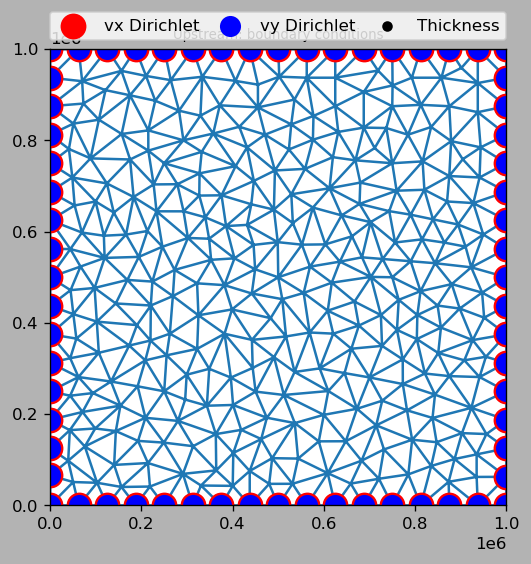

In [10]:
# ── Upstream ──────────────────────────────────────────────────────────────
# 'BC' is a special data string that triggers plot_BC internally
plotmodel(md,
          'data', 'BC',
          'title', 'Upstream: boundary conditions')
plt.tight_layout()

No ice-front (Neumann) elements found to plot.


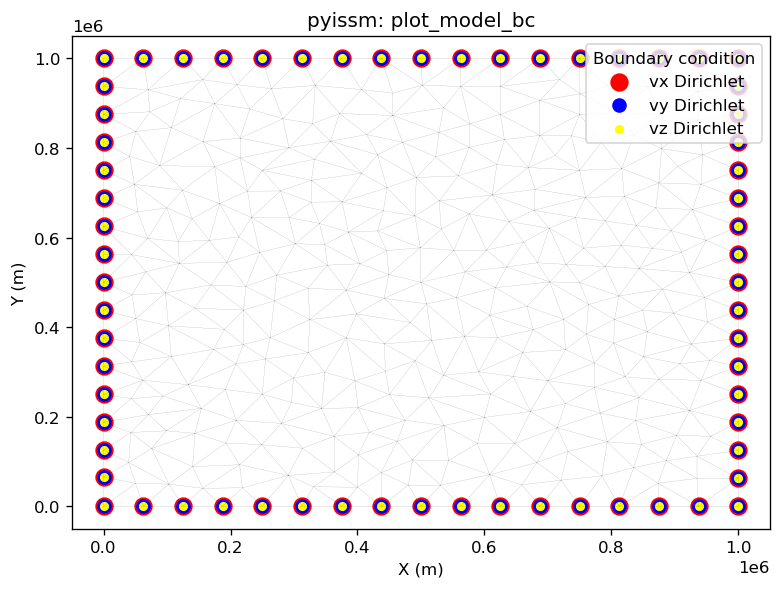

In [11]:
# ── pyissm ────────────────────────────────────────────────────────────────
fig, ax = pyissm.plot.plot_model_bc(md)
ax.set_title('pyissm: plot_model_bc')
plt.show()

---
## 5  Contour overlay

Overlay contour lines of the **same field** (velocity magnitude) on the colour plot.
Note: upstream `plotmodel` always contours the same data as `'data'` — there is no `'contourdata'` option for a separate field.

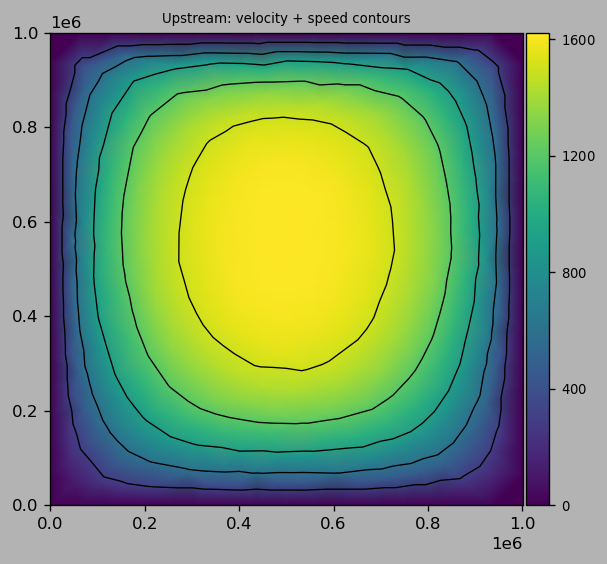

In [12]:
# ── Upstream ──────────────────────────────────────────────────────────────
# Contours are specified via 'contourlevels', 'contourcolors' options
plotmodel(md,
          'data', speed,
          'colormap', 'viridis',
          'contourlevels', 5,
          'contourcolors', 'k',
          'contourlinewidths', 0.8,
          'title', 'Upstream: velocity + speed contours')
plt.tight_layout()

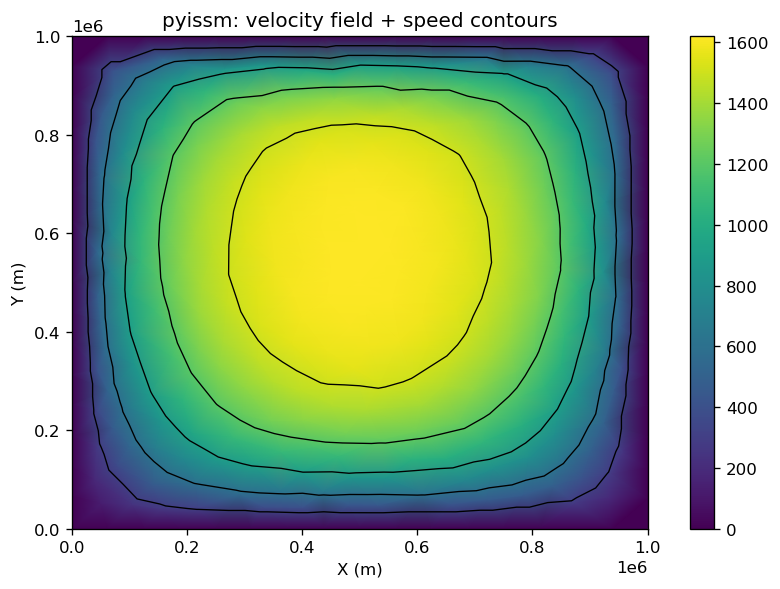

In [13]:
# ── pyissm ────────────────────────────────────────────────────────────────
# Contour the same field (speed) with the same number of levels as upstream
fig, ax, im = pyissm.plot.plot_model_field(md, speed, cmap='viridis', show_cbar=True)
pyissm.plot.plot_contour(
    md, speed,
    levels=5, ax=ax,
    colors='k', linewidths=0.8,
)
ax.set_title('pyissm: velocity field + speed contours')
plt.show()


---
## 6  Quiver plot

Arrow plot of velocity direction and magnitude.

the current value for "scaling" is 0.029896757846732267, increase it to shorten the arrows


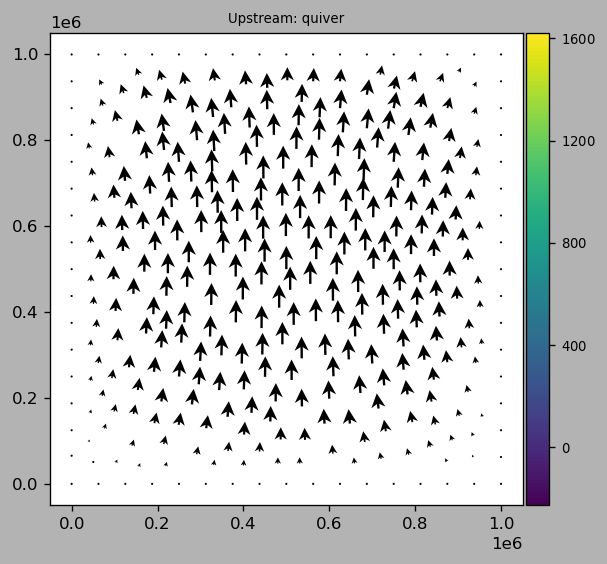

In [14]:
# ── Upstream ──────────────────────────────────────────────────────────────
# Pass vx and vy stacked; upstream detects vector data
import numpy as np
vxy = np.column_stack((md.initialization.vx, md.initialization.vy))

plotmodel(md,
          'data', vxy,
          'title', 'Upstream: quiver',
          'quivercol', 'k')
plt.tight_layout()

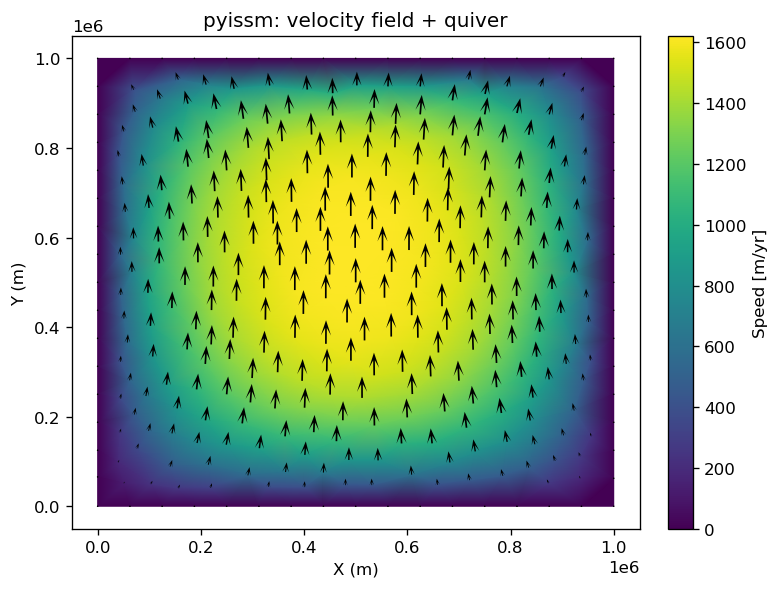

In [15]:
# ── pyissm ────────────────────────────────────────────────────────────────
fig, ax, im = pyissm.plot.plot_model_field(
    md, speed, colormap='viridis', show_mesh=False
)
pyissm.plot.plot_quiver(
    md,
    vx=md.initialization.vx,
    vy=md.initialization.vy,
    ax=ax, color='k', width=3e-3
)
ax.set_title('pyissm: velocity field + quiver')
fig.colorbar(im, ax=ax, label='Speed [m/yr]')
plt.show()


---
## 7  Streamlines

Trace flow lines through the velocity field.

the current value for "scaling" is 0.029896757846732267, increase it to shorten the arrows


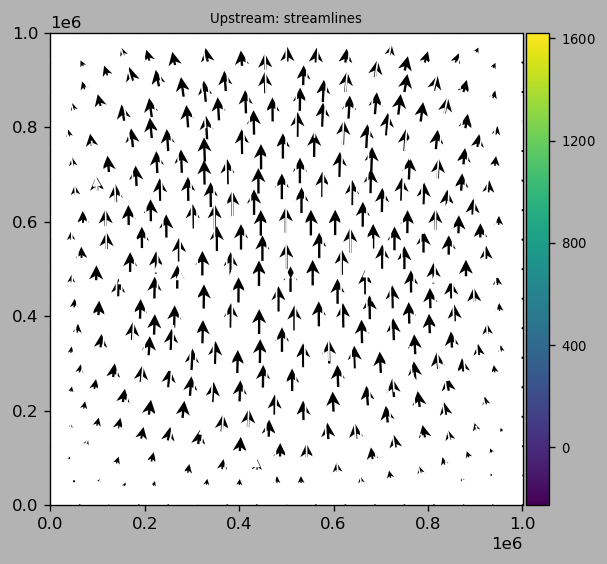

In [16]:
# ── Upstream ──────────────────────────────────────────────────────────────
plotmodel(md,
          'data', vxy,
          'streamlines', 1,
          'streamlinescolor', 'w',
          'streamlinesdensity', 1.5,
          'colormap', 'viridis',
          'title', 'Upstream: streamlines')
plt.tight_layout()

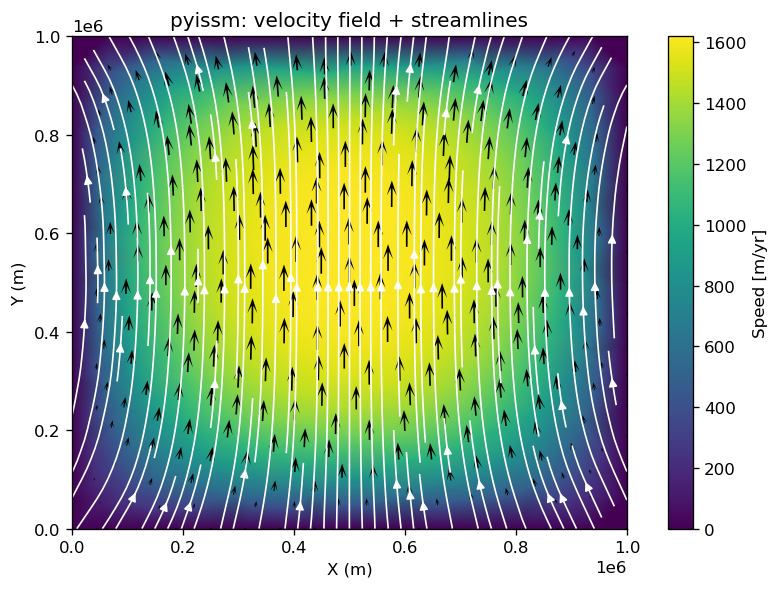

In [18]:
# ── pyissm ────────────────────────────────────────────────────────────────
fig, ax, im = pyissm.plot.plot_model_field(
    md, speed, colormap='viridis', show_mesh=False
)
pyissm.plot.plot_streamlines(
    md,
    vx=md.initialization.vx,
    vy=md.initialization.vy,
    ax=ax, color='w', density=1.5
)
pyissm.plot.plot_quiver(
    md,
    vx=md.initialization.vx,
    vy=md.initialization.vy,
    ax=ax, color='k', width=3e-3
)
ax.set_title('pyissm: velocity field + streamlines')
fig.colorbar(im, ax=ax, label='Speed [m/yr]')
plt.show()

---
## 8  Gridded interpolation

Interpolate an unstructured mesh field to a regular grid and display as an image.
The upstream uses the compiled C routine `InterpFromMeshToGrid`; pyissm uses `scipy.interpolate.griddata`.

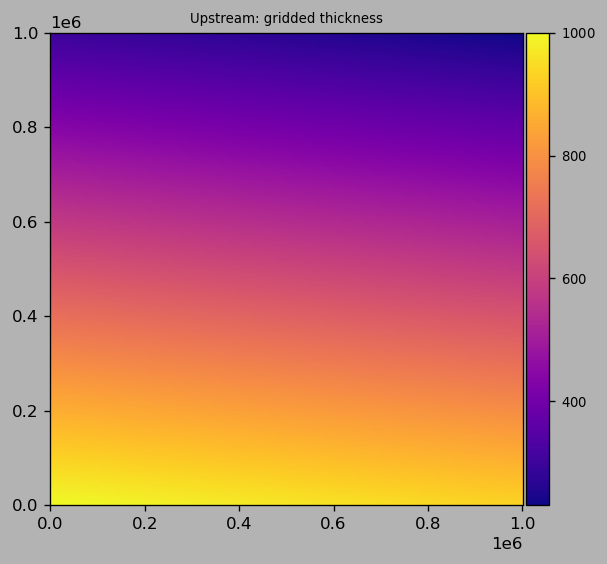

In [19]:
# ── Upstream ──────────────────────────────────────────────────────────────
plotmodel(md,
          'data', md.geometry.thickness,
          'gridded', 1,
          'posting', 5000,
          'colormap', 'plasma',
          'title', 'Upstream: gridded thickness')
plt.tight_layout()

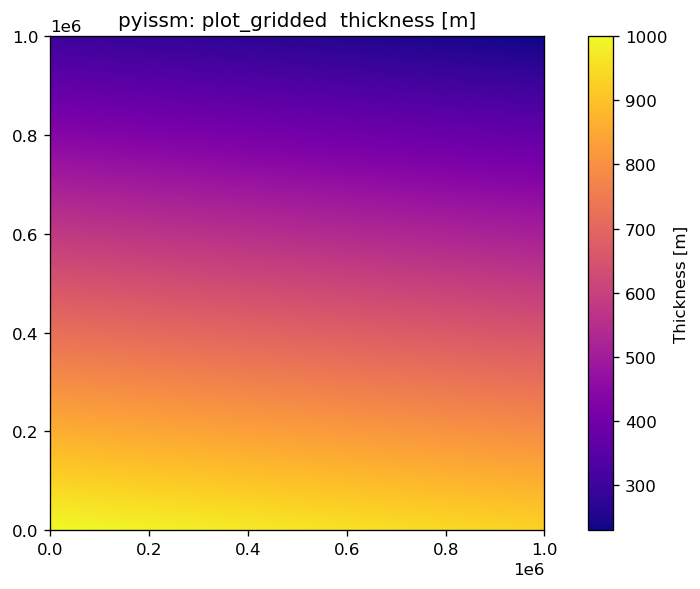

In [20]:
# ── pyissm ────────────────────────────────────────────────────────────────
fig, ax, im = pyissm.plot.plot_gridded(
    md, md.geometry.thickness,
    posting=5000, colormap='plasma'
)
ax.set_title('pyissm: plot_gridded  thickness [m]')
fig.colorbar(im, ax=ax, label='Thickness [m]')
plt.show()

---
## 9  Element and vertex numbering

Label elements/vertices — useful for debugging small meshes.

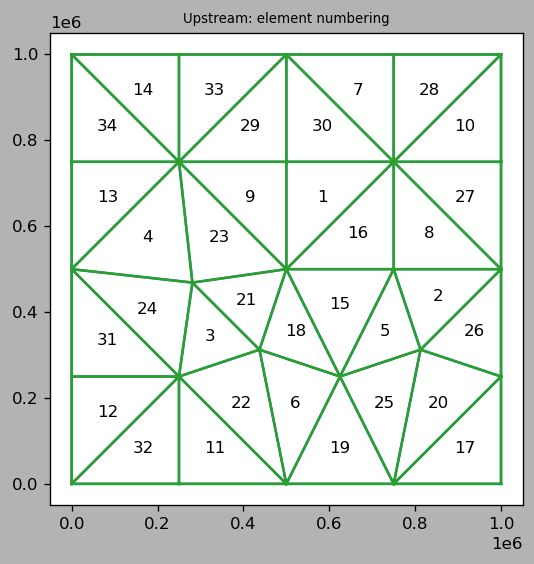

In [21]:
# ── Upstream ──────────────────────────────────────────────────────────────
# Build a tiny mesh for legibility
md_tiny = pyissm.model.mesh.triangle(
    pyissm.model.Model(), '../assets/Exp/Square.exp', 200000
)
plotmodel(md_tiny,
          'data', 'elementnumbering',
          'title', 'Upstream: element numbering')
plt.tight_layout()

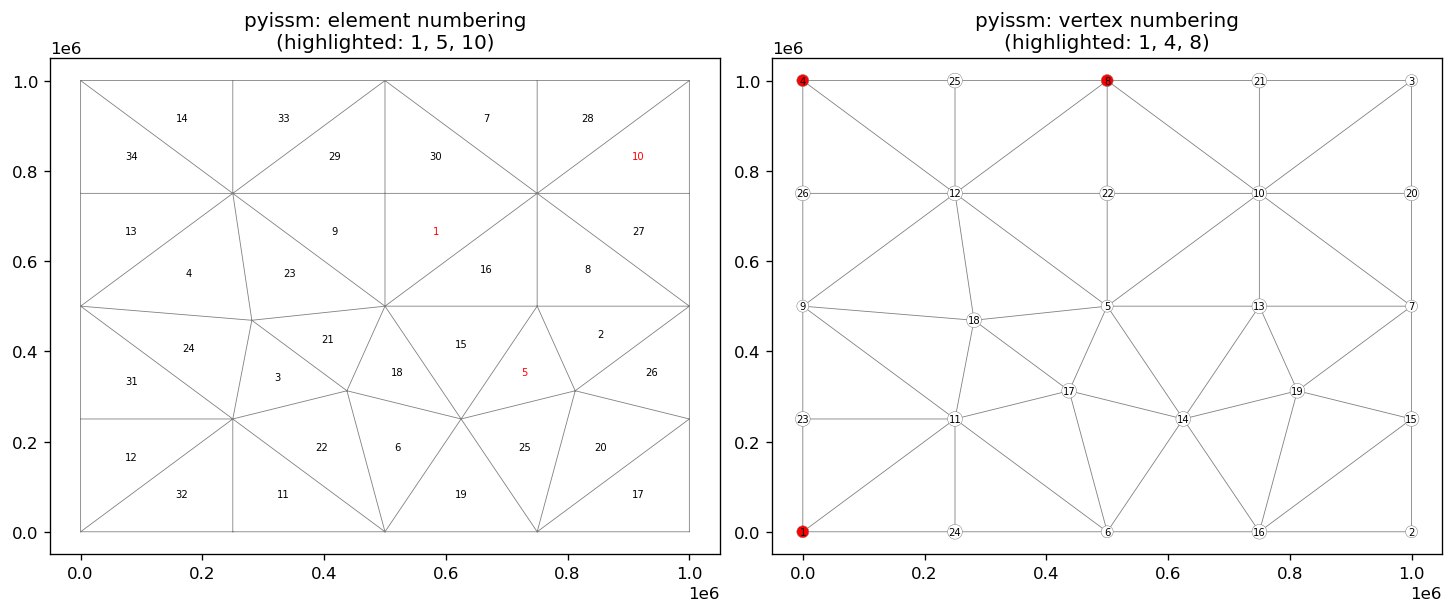

In [22]:
# ── pyissm ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

pyissm.plot.plot_elementnumbering(md_tiny, ax=axes[0], highlight=[1, 5, 10])
axes[0].set_title('pyissm: element numbering\n(highlighted: 1, 5, 10)')

pyissm.plot.plot_vertexnumbering(md_tiny, ax=axes[1], highlight=[1, 4, 8])
axes[1].set_title('pyissm: vertex numbering\n(highlighted: 1, 4, 8)')

plt.show()

---
## 10  Ice front and grounding line

Highlight elements that span the ocean/ice and grounding-line boundaries.

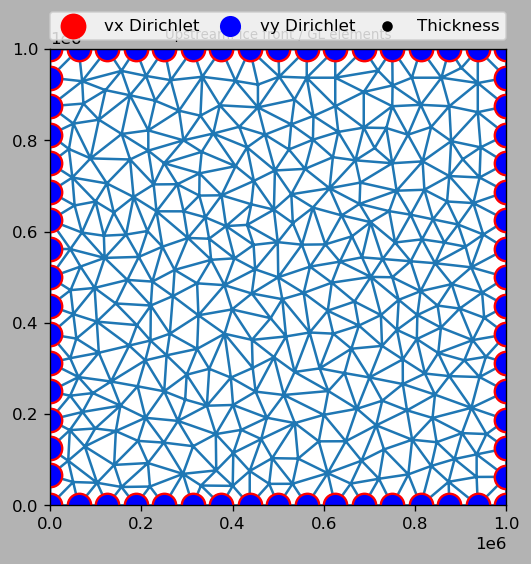

In [23]:
# ── Upstream ──────────────────────────────────────────────────────────────
plotmodel(md,
          'data', 'BC',
          'icefront', 'on',
          'title', 'Upstream: ice front / GL elements')
plt.tight_layout()

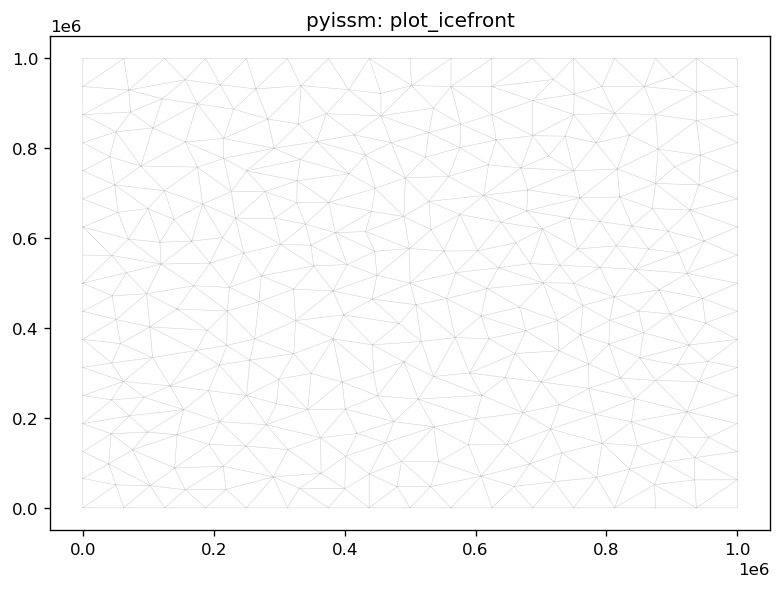

In [24]:
# ── pyissm ────────────────────────────────────────────────────────────────
fig, ax = pyissm.plot.plot_icefront(
    md,
    ice_color='tab:blue',
    gl_color='tab:green',
    alpha=0.7
)
ax.set_title('pyissm: plot_icefront')
plt.show()

---
## 11  Custom ISSM colormaps

The upstream `cmaptools` colormaps are available in `pyissm.plot.colormaps`.

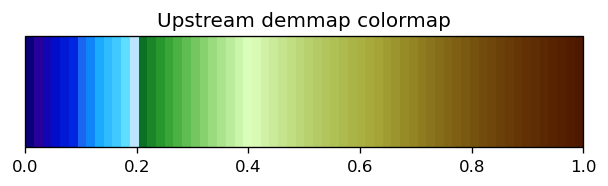

In [30]:
# ── Upstream ──────────────────────────────────────────────────────────────
from demmap import demmap
from matplotlib.colors import ListedColormap

cmap_dem_up = ListedColormap(demmap(64, -500, 2000))

fig, ax = plt.subplots(figsize=(6, 1.2))
plt.colorbar(plt.cm.ScalarMappable(cmap=cmap_dem_up), cax=ax, orientation='horizontal')
ax.set_title('Upstream demmap colormap')
plt.show()


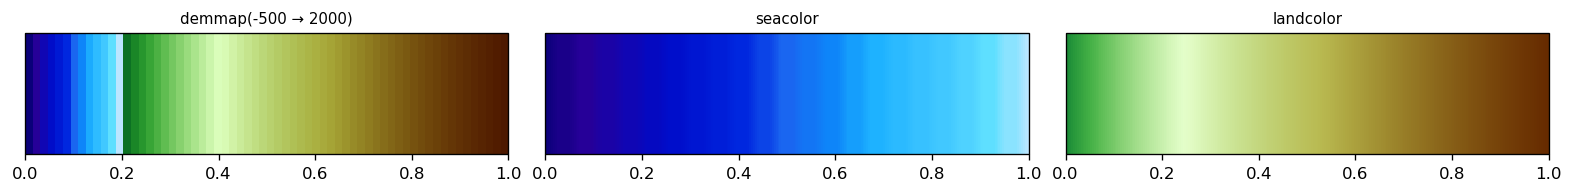

In [31]:
# ── pyissm ────────────────────────────────────────────────────────────────
import matplotlib
from pyissm.plot import colormaps as cm

# demmap: sea (blue) for z < 0, land (green-brown) for z > 0
cmap_dem = cm.demmap(ncolors=64, minZ=-500, maxZ=2000)

fig, axes = plt.subplots(1, 3, figsize=(13, 1.5), constrained_layout=True)

for ax, (name, cmap) in zip(axes, [
    ('demmap(-500 → 2000)', cmap_dem),
    ('seacolor',  matplotlib.colors.ListedColormap(cm.seacolor(256).T)),
    ('landcolor', matplotlib.colors.ListedColormap(cm.landcolor(256).T)),
]):
    plt.colorbar(
        plt.cm.ScalarMappable(cmap=cmap),
        cax=ax, orientation='horizontal'
    )
    ax.set_title(name, fontsize=9)

plt.show()

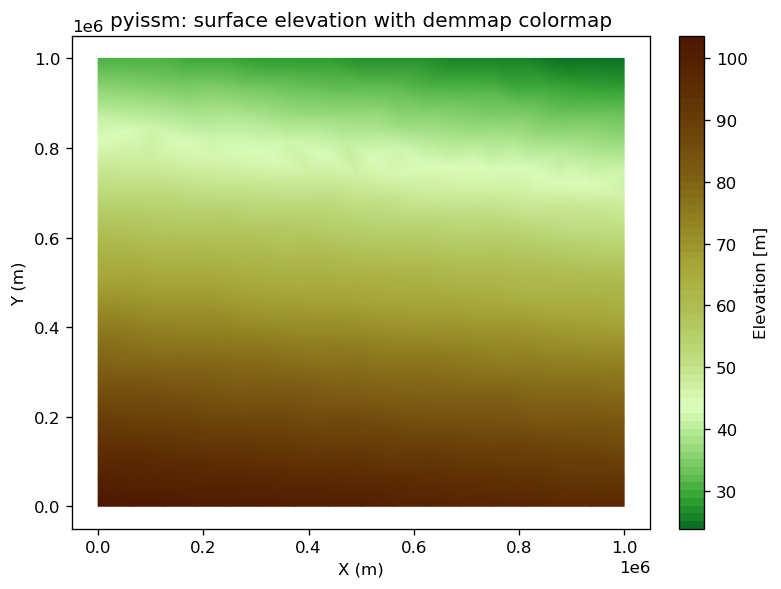

In [33]:
# Apply the DEM colormap to ice-surface elevation
z_min = md.geometry.surface.min()
z_max = md.geometry.surface.max()
cmap_surf = cm.demmap(ncolors=64, minZ=z_min, maxZ=z_max)

fig, ax, im = pyissm.plot.plot_model_field(
    md, md.geometry.surface,
    colormap=cmap_surf,
    vmin=z_min, vmax=z_max
)
ax.set_title('pyissm: surface elevation with demmap colormap')
fig.colorbar(im, ax=ax, label='Elevation [m]')
plt.show()


---
## 12  Composing multiple plots (pyissm advantage)

Because pyissm functions return `(fig, ax)` / accept an existing `ax`, you can compose
any combination of overlays in a standard matplotlib subplot grid — something the
upstream `plotmodel` grid cannot do directly.

ValueError: too many values to unpack (expected 2)

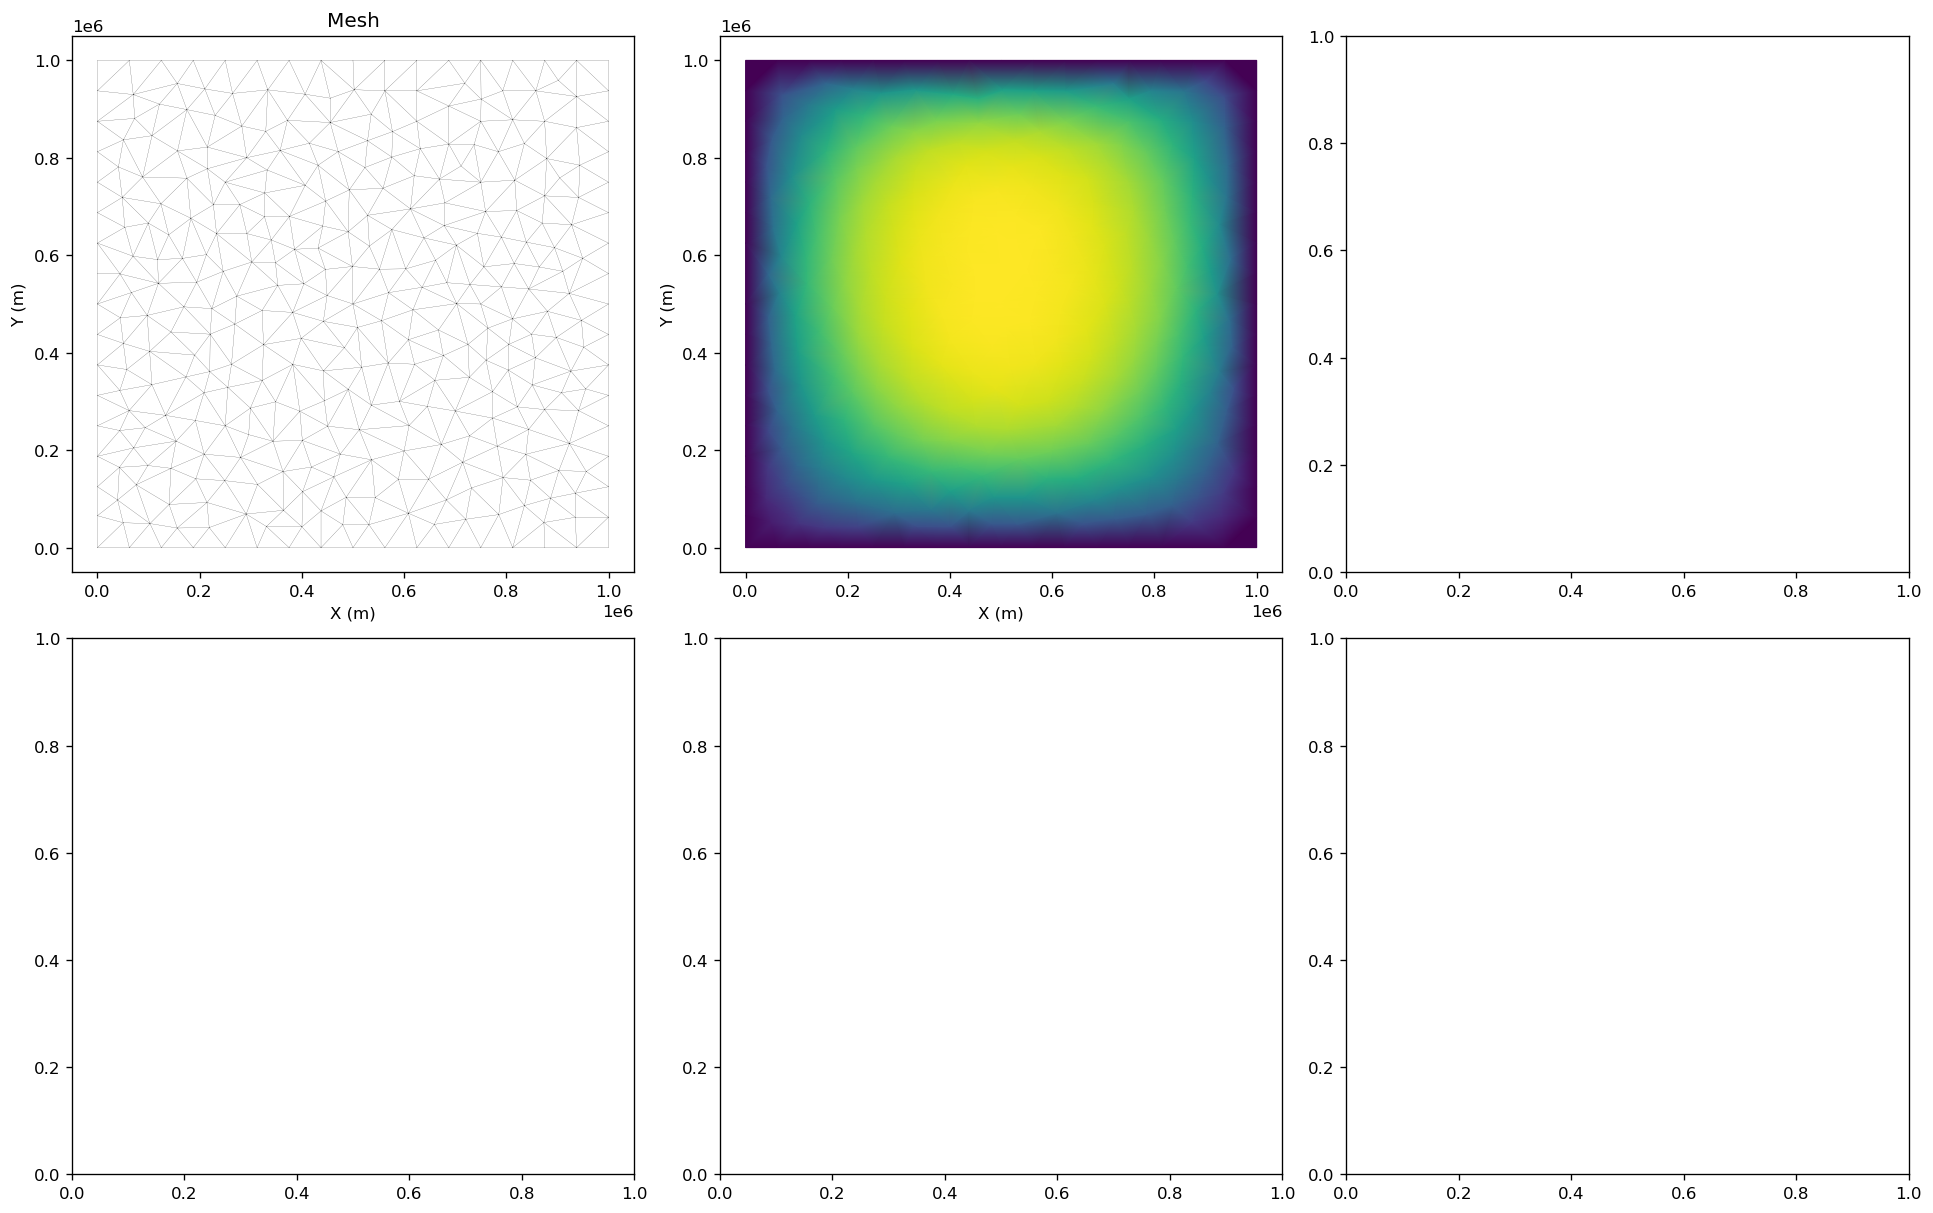

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

# ── (0,0) mesh
pyissm.plot.plot_mesh2d(md, ax=axes[0, 0])
axes[0, 0].set_title('Mesh')

# ── (0,1) velocity magnitude + contours
_, _, im1 = pyissm.plot.plot_model_field(
    md, speed, ax=axes[0, 1], colormap='viridis', show_mesh=False
)
pyissm.plot.plot_contour(
    md, md.geometry.thickness, levels=5,
    ax=axes[0, 1], colors='w', linewidths=0.7
)
fig.colorbar(im1, ax=axes[0, 1], label='Speed [m/yr]')
axes[0, 1].set_title('|v| + thickness contours')

# ── (0,2) gridded thickness  (returns (ax, im) when ax is supplied)
_, im2 = pyissm.plot.plot_gridded(
    md, md.geometry.thickness, ax=axes[0, 2],
    posting=5000, colormap='plasma'
)
fig.colorbar(im2, ax=axes[0, 2], label='Thickness [m]')
axes[0, 2].set_title('Gridded thickness')

# ── (1,0) quiver
_, _, im3 = pyissm.plot.plot_model_field(
    md, speed, ax=axes[1, 0], colormap='magma', show_mesh=False
)
pyissm.plot.plot_quiver(
    md, ax=axes[1, 0], color='w', width=3e-3
)
fig.colorbar(im3, ax=axes[1, 0], label='Speed [m/yr]')
axes[1, 0].set_title('Quiver')

# ── (1,1) streamlines
_, _, im4 = pyissm.plot.plot_model_field(
    md, speed, ax=axes[1, 1], colormap='cividis', show_mesh=False
)
pyissm.plot.plot_streamlines(
    md, ax=axes[1, 1], color='w', density=2
)
fig.colorbar(im4, ax=axes[1, 1], label='Speed [m/yr]')
axes[1, 1].set_title('Streamlines')

# ── (1,2) ice front
pyissm.plot.plot_icefront(md, ax=axes[1, 2])
axes[1, 2].set_title('Ice front / GL elements')

plt.suptitle('pyissm: composable subplot grid', fontsize=14, y=1.01)
plt.show()


---
## Summary

### Key API differences

```python
# ── Upstream ──────────────────────────────────────────────────────────────
# Single entry point; options are flat key-value pairs
plotmodel(md,
          'data', field,
          'colormap', 'viridis',
          'contourlevels', 5,
          'contourcolors', 'k')

# ── pyissm ────────────────────────────────────────────────────────────────
# Separate, composable functions; return (fig, ax) for full matplotlib control
fig, ax, im = pyissm.plot.plot_model_field(md, field, colormap='viridis')
pyissm.plot.plot_contour(md, field, levels=5, ax=ax, colors='k')
fig.colorbar(im, ax=ax)
```

### Function mapping

| Upstream `plotmodel` option | pyissm equivalent |
|---|---|
| `'data', 'mesh'` | `plot_mesh2d(md)` |
| `'data', field` | `plot_model_field(md, field)` |
| `'data', 'BC'` | `plot_model_bc(md)` |
| `'contourlevels', n` | `plot_contour(md, field, levels=n, ax=ax)` |
| `'data', vxy` (quiver) | `plot_quiver(md, vx=vx, vy=vy, ax=ax)` |
| `'streamlines', 1` | `plot_streamlines(md, ax=ax)` |
| `'gridded', 1` | `plot_gridded(md, field)` |
| `'data', 'elementnumbering'` | `plot_elementnumbering(md)` |
| `'icefront', 'on'` | `plot_icefront(md)` |
| `cmaptools.getcolormap(opts)` | `pyissm.plot.colormaps.get_colormap(name)` |
| `'colormap', 'dem'` | `pyissm.plot.colormaps.demmap(n, zmin, zmax)` |